# 3 — Stock Predictor Engine

**Mandatory Task A**: Predict next-day price direction (up/down).

- Train XGBoost and LightGBM classifiers on pooled multi-stock data
- Time-aware train/test split (no look-ahead)
- Evaluate: Accuracy, Precision, Recall, F1, Directional Accuracy
- SHAP-based explainability

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

from src.preprocess import load_all_stocks
from src.indicators import add_all_indicators
from src.explainability import get_feature_importance, explain_with_shap

sns.set_style('whitegrid')
%matplotlib inline

## 3.1 Prepare Data

In [2]:
FEATURE_COLS = [
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Position', 'BB_Width', 'ATR',
    'Price_vs_SMA20', 'Price_vs_SMA50', 'Price_vs_SMA200',
    'Volatility_20', 'Volume_Ratio',
    'Returns_Lag1', 'Returns_Lag2', 'Returns_Lag3', 'Returns_Lag5',
    'DayOfWeek', 'Month',
]

stocks = load_all_stocks()

frames = []
for sym, df in stocks.items():
    df = add_all_indicators(df)
    clean = df.dropna(subset=FEATURE_COLS + ['Target'])
    frames.append(clean)

# Keep DatetimeIndex and sort by date for a true temporal split
pool = pd.concat(frames).sort_index()
X = pool[FEATURE_COLS].values
y = pool['Target'].values

print(f'Total samples: {len(pool)}')
print(f'Class balance: Up={y.mean():.3f}  Down={1-y.mean():.3f}')
print(f'Date range: {pool.index.min()} → {pool.index.max()}')

Total samples: 225441
Class balance: Up=0.505  Down=0.495
Date range: 2000-10-19 00:00:00 → 2021-04-30 00:00:00


In [3]:
# Time-aware split: train on earlier dates, test on later dates
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Train period: {pool.index[0].date()} → {pool.index[split-1].date()}')
print(f'Test  period: {pool.index[split].date()} → {pool.index[-1].date()}')

Train: 180352  |  Test: 45089
Train period: 2000-10-19 → 2017-08-09
Test  period: 2017-08-09 → 2021-04-30


## 3.2 Train XGBoost Classifier

In [4]:
# FIX: use_label_encoder removed — was deprecated in XGBoost 1.6 and crashes in XGBoost 2.0+
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print('=== XGBoost Results ===')
print(classification_report(y_test, xgb_preds, target_names=['Down', 'Up']))

=== XGBoost Results ===
              precision    recall  f1-score   support

        Down       0.51      0.38      0.44     22446
          Up       0.51      0.64      0.57     22643

    accuracy                           0.51     45089
   macro avg       0.51      0.51      0.50     45089
weighted avg       0.51      0.51      0.50     45089



## 3.3 Train LightGBM Classifier

In [5]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
)
lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_test)
print('=== LightGBM Results ===')
print(classification_report(y_test, lgbm_preds, target_names=['Down', 'Up']))

=== LightGBM Results ===
              precision    recall  f1-score   support

        Down       0.51      0.37      0.43     22446
          Up       0.51      0.65      0.57     22643

    accuracy                           0.51     45089
   macro avg       0.51      0.51      0.50     45089
weighted avg       0.51      0.51      0.50     45089



c:\Users\Akhil\Desktop\Projects\Data-Driven Investment Intelligence Using NIFTY-50 Market Data\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3.4 Model Comparison

In [6]:
def eval_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        # Directional Accuracy = % of correct up/down calls (equals Accuracy for binary classifier)
        'Directional Accuracy': float((y_true == y_pred).mean()),
    }

comparison = pd.DataFrame({
    'XGBoost': eval_metrics(y_test, xgb_preds),
    'LightGBM': eval_metrics(y_test, lgbm_preds),
})
comparison

,XGBoost,LightGBM
Accuracy,0.512187,0.510701
Precision,0.511394,0.510138
Recall,0.642229,0.645586
F1 Score,0.569393,0.569925
Directional Accuracy,0.512187,0.510701


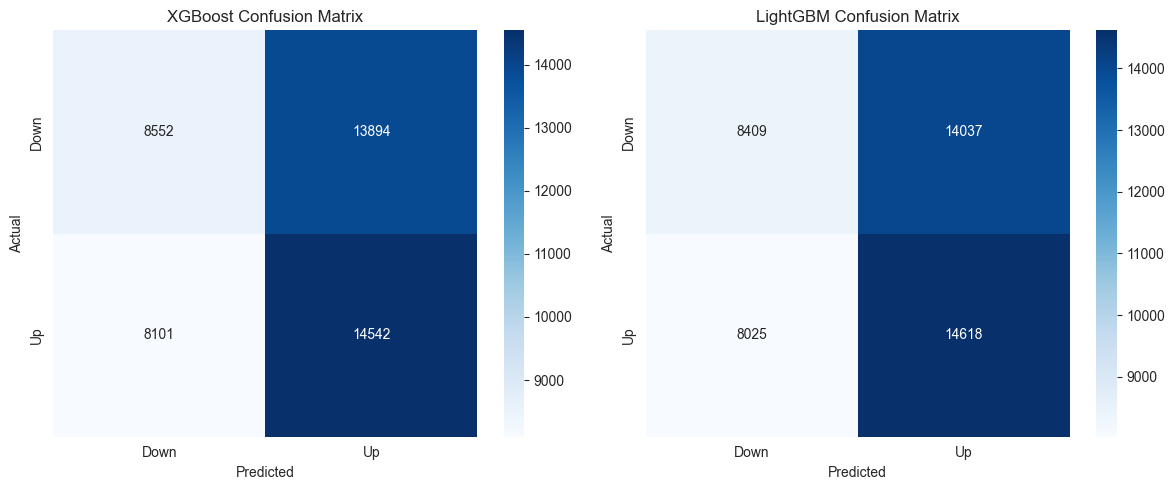

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name in [(axes[0], xgb_preds, 'XGBoost'), (axes[1], lgbm_preds, 'LightGBM')]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 3.5 Feature Importance

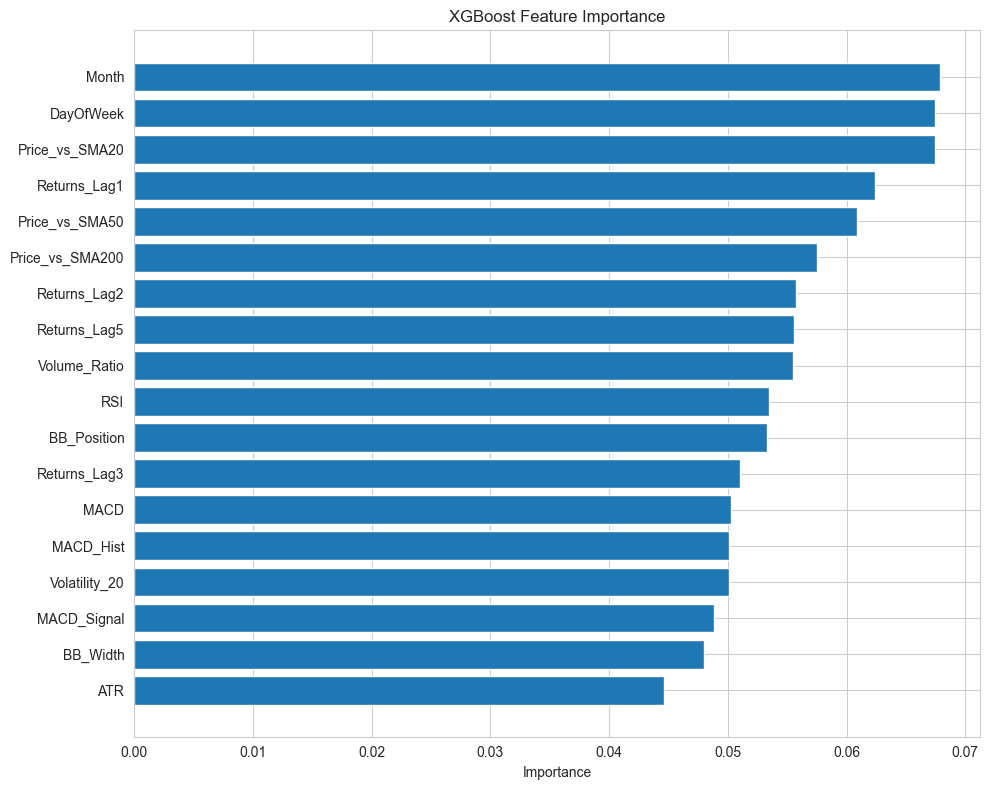

In [8]:
importance = get_feature_importance(xgb_model, FEATURE_COLS)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance['Feature'], importance['Importance'])
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3.6 SHAP Explainability

c:\Users\Akhil\Desktop\Projects\Data-Driven Investment Intelligence Using NIFTY-50 Market Data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


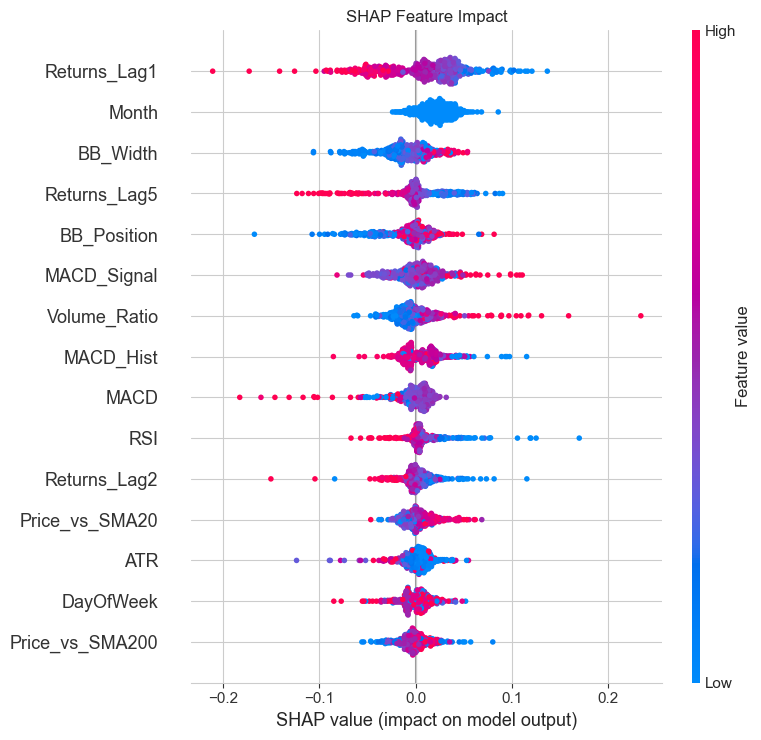

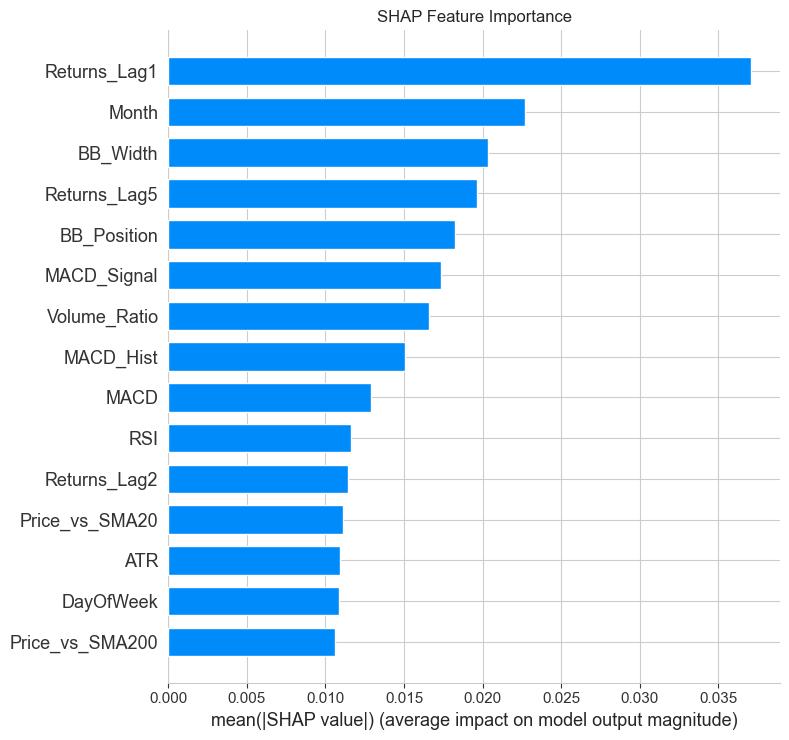

In [9]:
# Use a sample of test data for SHAP (full set is slow)
X_test_df = pd.DataFrame(X_test[:500], columns=FEATURE_COLS)
shap_values = explain_with_shap(xgb_model, X_test_df, max_display=15)

## 3.7 Save Best Model

In [10]:
model_dir = Path('..') / 'models'
model_dir.mkdir(exist_ok=True)

joblib.dump(xgb_model, model_dir / 'direction_xgb.pkl')
joblib.dump(lgbm_model, model_dir / 'direction_lgbm.pkl')
print('Models saved to models/')

Models saved to models/


## 3.8 Key Findings

- **Directional accuracy** slightly above 50% — typical for daily stock prediction
- **MACD histogram and RSI** tend to be the strongest predictors
- **Lag return features** capture short-term momentum
- **SHAP analysis** shows non-linear feature interactions drive predictions
- Daily direction prediction is inherently noisy; the model adds value when combined with portfolio/risk tools